# Walmart Retail Data Analytics
## Complete Python Analysis — 2019 to 2023
---
**Dataset:** `Walmart org.csv` · 10,051 raw rows · 11 columns  
**Scope:** 100 Walmart stores across 98 Texas cities  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Plotly  
**Author:** Data Analytics Project


## 1. Setup — Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.width", 200)

# Palette
PALETTE = ["#3b82f6","#f97316","#22c55e","#ef4444","#a855f7","#14b8a6"]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.1)

MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
DOW_ORDER   = ["Monday","Tuesday","Wednesday","Thursday",
               "Friday","Saturday","Sunday"]

print("Libraries loaded successfully.")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")
print(f"  seaborn {sns.__version__}")


Libraries loaded successfully.
  pandas  3.0.5
  numpy   2.5.3
  seaborn 0.13.2


## 2. Data Loading

In [2]:
raw = pd.read_csv("Walmart org.csv")
df  = raw.copy()

print(f"Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory : {df.memory_usage(deep=True).sum()/1024:.1f} KB")
df.head()


Shape  : 10,051 rows x 11 columns
Memory : 1467.8 KB


,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.00,05/01/19,13:08:00,Ewallet,9.10,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.00,08/03/19,10:29:00,Cash,9.60,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.00,03/03/19,13:23:00,Credit card,7.40,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.00,27/01/19,20:33:00,Ewallet,8.40,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.00,08/02/19,10:37:00,Ewallet,5.30,0.48


In [3]:
df.dtypes


invoice_id          int64
Branch                str
City                  str
category              str
unit_price            str
quantity          float64
date                  str
time                  str
payment_method        str
rating            float64
profit_margin     float64
dtype: object

## 3. Data Inspection

### 3.1 Basic Info

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  str    
 2   City            10051 non-null  str    
 3   category        10051 non-null  str    
 4   unit_price      10020 non-null  str    
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  str    
 7   time            10051 non-null  str    
 8   payment_method  10051 non-null  str    
 9   rating          10051 non-null  float64
 10  profit_margin   10051 non-null  float64
dtypes: float64(3), int64(1), str(7)
memory usage: 1.4 MB


### 3.2 Unique Values per Column

In [5]:
for col in df.columns:
    n = df[col].nunique()
    sample = df[col].dropna().unique()[:6].tolist()
    print(f"  {col:<20s} {n:>5} unique  |  sample: {sample}")


  invoice_id           10000 unique  |  sample: [1, 2, 3, 4, 5, 6]
  Branch                 100 unique  |  sample: ['WALM003', 'WALM048', 'WALM067', 'WALM064', 'WALM013', 'WALM026']
  City                    98 unique  |  sample: ['San Antonio', 'Harlingen', 'Haltom City', 'Bedford', 'Irving', 'Denton']
  category                 6 unique  |  sample: ['Health and beauty', 'Electronic accessories', 'Home and lifestyle', 'Sports and travel', 'Food and beverages', 'Fashion accessories']
  unit_price            1008 unique  |  sample: ['$74.69', '$15.28', '$46.33', '$58.22', '$86.31', '$85.39']
  quantity                10 unique  |  sample: [7.0, 5.0, 8.0, 6.0, 10.0, 2.0]
  date                  1460 unique  |  sample: ['05/01/19', '08/03/19', '03/03/19', '27/01/19', '08/02/19', '25/03/19']
  time                  1001 unique  |  sample: ['13:08:00', '10:29:00', '13:23:00', '20:33:00', '10:37:00', '18:30:00']
  payment_method           3 unique  |  sample: ['Ewallet', 'Cash', 'Credit card

### 3.3 Missing Values

In [6]:
missing = pd.DataFrame({
    "Missing Count" : df.isnull().sum(),
    "Missing %"     : (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing["Missing Count"] > 0]


,Missing Count,Missing %
unit_price,31,0.31
quantity,31,0.31


### 3.4 Duplicate Records

In [7]:
total_dups = df.duplicated().sum()
print(f"Fully duplicate rows : {total_dups}")
print(f"invoice_id duplicates: {df['invoice_id'].duplicated().sum()}")

dup_ids = df[df.duplicated(keep=False)]["invoice_id"]
print(f"Duplicate invoice_id range: {dup_ids.min()} - {dup_ids.max()}")


Fully duplicate rows : 51
invoice_id duplicates: 51
Duplicate invoice_id range: 9950 - 10000


### 3.5 Statistical Summary

In [8]:
df.describe(include="all")


,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
count,10051.00,10051,10051,10051,10020,10020.00,10051,10051,10051,10051.00,10051.00
unique,NaN,100,98,6,1008,NaN,1460,1001,3,NaN,NaN
top,NaN,WALM058,Weslaco,Fashion accessories,$63,NaN,01/12/21,15:48:00,Credit card,NaN,NaN
freq,NaN,240,399,4579,159,NaN,48,33,4260,NaN,NaN
mean,5025.74,NaN,NaN,NaN,NaN,2.35,NaN,NaN,NaN,5.83,0.39
std,2901.17,NaN,NaN,NaN,NaN,1.60,NaN,NaN,NaN,1.76,0.09
min,1.00,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,3.00,0.18
25%,2513.50,NaN,NaN,NaN,NaN,1.00,NaN,NaN,NaN,4.00,0.33
50%,5026.00,NaN,NaN,NaN,NaN,2.00,NaN,NaN,NaN,6.00,0.33
75%,7538.50,NaN,NaN,NaN,NaN,3.00,NaN,NaN,NaN,7.00,0.48


### 3.6 Date Range & Time Span

In [9]:
df["_date_tmp"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
print(f"Date range: {df['_date_tmp'].min().date()} to {df['_date_tmp'].max().date()}")
print(f"Years covered: {sorted(df['_date_tmp'].dt.year.unique())}")
df.drop(columns=["_date_tmp"], inplace=True)


Date range: 2019-01-01 to 2023-12-31
Years covered: [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]


## 4. Data Cleaning
Every decision is explained. The original dataset is never modified.


### 4.1 Remove Exact Duplicate Rows

In [10]:
# Reason: 51 rows (invoice_id 9950-10000) are fully identical to earlier rows.
# This is a systematic re-load artefact at the tail of the file.
before = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Rows removed : {before - len(df)}")
print(f"Rows after   : {len(df):,}")


Rows removed : 51
Rows after   : 10,000


### 4.2 Drop Rows with Missing unit_price / quantity

In [11]:
# Reason: Both fields are absent together in the same 31 rows.
# No revenue or profit metric can be computed. 0.31% loss is acceptable.
mask_miss = df["unit_price"].isna() | df["quantity"].isna()
print(f"Rows affected: {mask_miss.sum()}")
df = df[~mask_miss].reset_index(drop=True)
print(f"Rows after   : {len(df):,}")


Rows affected: 31
Rows after   : 9,969


### 4.3 Fix unit_price — Strip '$' and Cast to float

In [12]:
# Reason: Stored as string '$xx.xx'; must be numeric for all calculations.
df["unit_price"] = pd.to_numeric(
    df["unit_price"].astype(str).str.replace("$", "", regex=False).str.strip(),
    errors="coerce")
print(f"unit_price dtype  : {df['unit_price'].dtype}")
print(f"Remaining NaN     : {df['unit_price'].isna().sum()}")
df["unit_price"].describe()


unit_price dtype  : float64
Remaining NaN     : 0


count   9969.00
mean      50.62
std       21.20
min       10.08
25%       32.00
50%       51.00
75%       69.00
max       99.96
Name: unit_price, dtype: float64

### 4.4 Cast quantity to Integer

In [13]:
# Reason: All values are whole numbers 1-10; float64 was a load artefact.
df["quantity"] = df["quantity"].astype("Int8")
print(f"quantity dtype: {df['quantity'].dtype}")
df["quantity"].value_counts().sort_index()


quantity dtype: Int8


quantity
1     3142
2     2965
3     3155
4      109
5      102
6       98
7      102
8       85
9       92
10     119
Name: count, dtype: Int64

### 4.5 Parse Date Column

In [14]:
# Reason: 'DD/MM/YY' string cannot be used for time-series analysis.
# dayfirst=True is required to avoid day/month swap.
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%y", dayfirst=True, errors="coerce")
print(f"Parse failures: {df['date'].isna().sum()}")
print(f"Date range    : {df['date'].min().date()} -> {df['date'].max().date()}")


Parse failures: 0
Date range    : 2019-01-01 -> 2023-12-31


### 4.6 Parse Time Column

In [15]:
# Reason: 'HH:MM:SS' string needs parsing for hour-level analysis.
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S", errors="coerce").dt.time
print(f"Parse failures: {df['time'].isna().sum()}")


Parse failures: 0


### 4.7 Engineer Derived Columns

In [16]:
# total_sale and gross_profit are the two core financial metrics.
df["total_sale"]   = (df["unit_price"] * df["quantity"].astype(float)).round(2)
df["gross_profit"] = (df["total_sale"] * df["profit_margin"]).round(2)

print(f"total_sale   range: ${df['total_sale'].min():.2f} - ${df['total_sale'].max():.2f}")
print(f"gross_profit range: ${df['gross_profit'].min():.2f} - ${df['gross_profit'].max():.2f}")


total_sale   range: $10.17 - $993.00
gross_profit range: $2.70 - $507.72


### 4.8 Extract Date / Time Components

In [17]:
df["year"]        = df["date"].dt.year.astype("Int16")
df["month"]       = df["date"].dt.month.astype("Int8")
df["month_name"]  = pd.Categorical(df["date"].dt.strftime("%b"),
                                    categories=MONTH_ORDER, ordered=True)
df["day_of_week"] = pd.Categorical(df["date"].dt.day_name(),
                                    categories=DOW_ORDER, ordered=True)
df["hour"]        = pd.to_datetime(
    df["time"].astype(str), format="%H:%M:%S", errors="coerce"
).dt.hour.astype("Int8")

print("New columns: year, month, month_name, day_of_week, hour")


New columns: year, month, month_name, day_of_week, hour


### 4.9 Validate Categorical Columns

In [18]:
for col in ["Branch","City","category","payment_method"]:
    df[col] = df[col].astype(str).str.strip()

print("payment_method values:", sorted(df["payment_method"].unique()))
print("category values      :", sorted(df["category"].unique()))

# Convert to Categorical
for col in ["Branch","City","category","payment_method"]:
    df[col] = df[col].astype("category")
print("Categorical dtype applied.")


payment_method values: ['Cash', 'Credit card', 'Ewallet']
category values      : ['Electronic accessories', 'Fashion accessories', 'Food and beverages', 'Health and beauty', 'Home and lifestyle', 'Sports and travel']
Categorical dtype applied.


### 4.10 Outlier Review

In [19]:
print(f"{'Column':<18} {'Q1':>7} {'Q3':>7} {'IQR':>7} {'Lower fence':>12} {'Upper fence':>12} {'Outliers':>9}")
print("-" * 80)
for col in ["unit_price","quantity","rating"]:
    vals = df[col].astype(float)
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((vals < lo) | (vals > hi)).sum()
    print(f"  {col:<16} {q1:>7.2f} {q3:>7.2f} {iqr:>7.2f} {lo:>12.2f} {hi:>12.2f} {n_out:>9}")

print()
print("Decision: No rows removed.")
print("  quantity 7-10 are valid bulk purchases (max=10 is catalogue limit).")
print("  unit_price and rating have zero IQR outliers.")


Column                  Q1      Q3     IQR  Lower fence  Upper fence  Outliers
--------------------------------------------------------------------------------
  unit_price         32.00   69.00   37.00       -23.50       124.50         0
  quantity            1.00    3.00    2.00        -2.00         6.00       398
  rating              4.00    7.00    3.00        -0.50        11.50         0

Decision: No rows removed.
  quantity 7-10 are valid bulk purchases (max=10 is catalogue limit).
  unit_price and rating have zero IQR outliers.


### 4.11 Final Column Order & Clean Summary

In [20]:
FINAL_COLS = [
    "invoice_id", "Branch", "City", "category",
    "unit_price", "quantity", "total_sale", "profit_margin", "gross_profit",
    "date", "year", "month", "month_name", "day_of_week",
    "time", "hour",
    "payment_method", "rating"
]
df = df[FINAL_COLS]

print("=" * 50)
print("CLEANING SUMMARY")
print("=" * 50)
print(f"  Original rows  : {len(raw):,}")
print(f"  Cleaned rows   : {len(df):,}")
print(f"  Rows removed   : {len(raw)-len(df):,}")
print(f"  Columns        : {df.shape[1]} (was {raw.shape[1]})")
print(f"  Missing values : {df.isnull().sum().sum()}")
print(f"  Duplicates     : {df.duplicated().sum()}")
print()
df.dtypes


CLEANING SUMMARY
  Original rows  : 10,051
  Cleaned rows   : 9,969
  Rows removed   : 82
  Columns        : 18 (was 11)
  Missing values : 0
  Duplicates     : 0



invoice_id                 int64
Branch                  category
City                    category
category                category
unit_price               float64
quantity                    Int8
total_sale               float64
profit_margin            float64
gross_profit             float64
date              datetime64[us]
year                       Int16
month                       Int8
month_name              category
day_of_week             category
time                      object
hour                        Int8
payment_method          category
rating                   float64
dtype: object

In [21]:
df.head()


,invoice_id,Branch,City,category,unit_price,quantity,total_sale,profit_margin,gross_profit,date,year,month,month_name,day_of_week,time,hour,payment_method,rating
0,1,WALM003,San Antonio,Health and beauty,74.69,7,522.83,0.48,250.96,2019-01-05,2019,1,Jan,Saturday,13:08:00,13,Ewallet,9.10
1,2,WALM048,Harlingen,Electronic accessories,15.28,5,76.40,0.48,36.67,2019-03-08,2019,3,Mar,Friday,10:29:00,10,Cash,9.60
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7,324.31,0.33,107.02,2019-03-03,2019,3,Mar,Sunday,13:23:00,13,Credit card,7.40
3,4,WALM064,Bedford,Health and beauty,58.22,8,465.76,0.33,153.70,2019-01-27,2019,1,Jan,Sunday,20:33:00,20,Ewallet,8.40
4,5,WALM013,Irving,Sports and travel,86.31,7,604.17,0.48,290.00,2019-02-08,2019,2,Feb,Friday,10:37:00,10,Ewallet,5.30


## 5. Exploratory Data Analysis (EDA)

### 5.1 Numerical Statistics

In [22]:
num_cols = ["unit_price","quantity","total_sale","gross_profit","profit_margin","rating"]
stats = df[num_cols].describe().T
stats["skew"]     = df[num_cols].skew()
stats["kurtosis"] = df[num_cols].kurtosis()
stats.round(3)


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
unit_price,9969.00,50.62,21.20,10.08,32.00,51.00,69.00,99.96,0.04,-1.10
quantity,9969.00,2.36,1.61,1.00,1.00,2.00,3.00,10.00,2.56,8.39
total_sale,9969.00,121.35,112.68,10.17,54.00,88.00,156.00,993.00,3.36,15.77
gross_profit,9969.00,47.76,47.18,2.70,20.46,34.65,60.48,507.72,3.70,20.46
profit_margin,9969.00,0.39,0.09,0.18,0.33,0.33,0.48,0.57,-0.35,-0.71
rating,9969.00,5.83,1.76,3.00,4.00,6.00,7.00,10.00,0.20,-0.83


### 5.2 Distribution of Key Numerical Variables

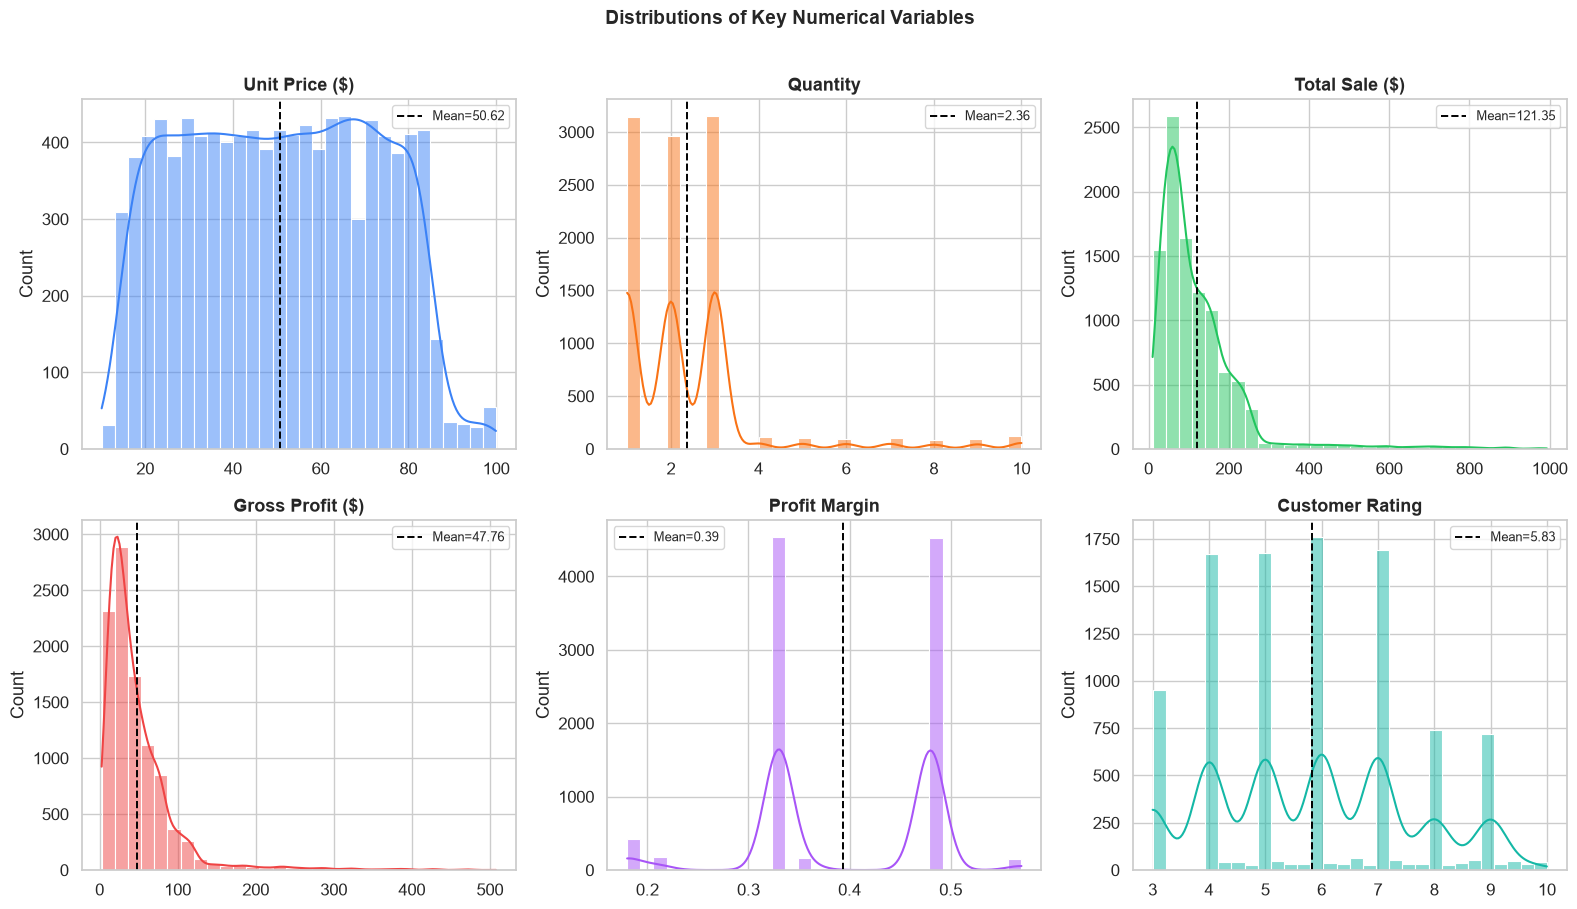

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
titles = ["Unit Price ($)","Quantity","Total Sale ($)",
          "Gross Profit ($)","Profit Margin","Customer Rating"]
for i, (col, title, color) in enumerate(zip(num_cols, titles, PALETTE)):
    sns.histplot(df[col].astype(float), bins=30, kde=True,
                 color=color, ax=axes[i], edgecolor="white")
    axes[i].set_title(title, fontweight="bold")
    axes[i].set_xlabel("")
    mean_val = df[col].astype(float).mean()
    axes[i].axvline(mean_val, color="black", linestyle="--", linewidth=1.4,
                    label=f"Mean={mean_val:.2f}")
    axes[i].legend(fontsize=9)
fig.suptitle("Distributions of Key Numerical Variables", fontsize=14,
             fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


### 5.3 Category Analysis

In [24]:
cat_stats = df.groupby("category", observed=True).agg(
    Transactions=("invoice_id","count"),
    Revenue=("total_sale","sum"),
    GrossProfit=("gross_profit","sum"),
    AvgBasket=("total_sale","mean"),
    AvgRating=("rating","mean"),
    AvgMargin=("profit_margin","mean")
).sort_values("Revenue", ascending=False)
cat_stats["Margin%"] = (cat_stats["AvgMargin"]*100).round(1)
cat_stats.round(2)


,Transactions,Revenue,GrossProfit,AvgBasket,AvgRating,AvgMargin,Margin%
category,,,,,,,
Fashion accessories,4538,489480.90,192314.92,107.86,5.78,0.39,39.30
Home and lifestyle,4520,489250.06,192213.64,108.24,5.74,0.39,39.50
Electronic accessories,419,78175.03,30772.46,186.58,5.91,0.39,39.30
Food and beverages,174,53471.28,21552.82,307.31,7.11,0.40,40.00
Sports and travel,166,52497.93,20613.86,316.25,6.92,0.38,38.20
Health and beauty,152,46851.18,18671.74,308.23,7.00,0.40,40.00


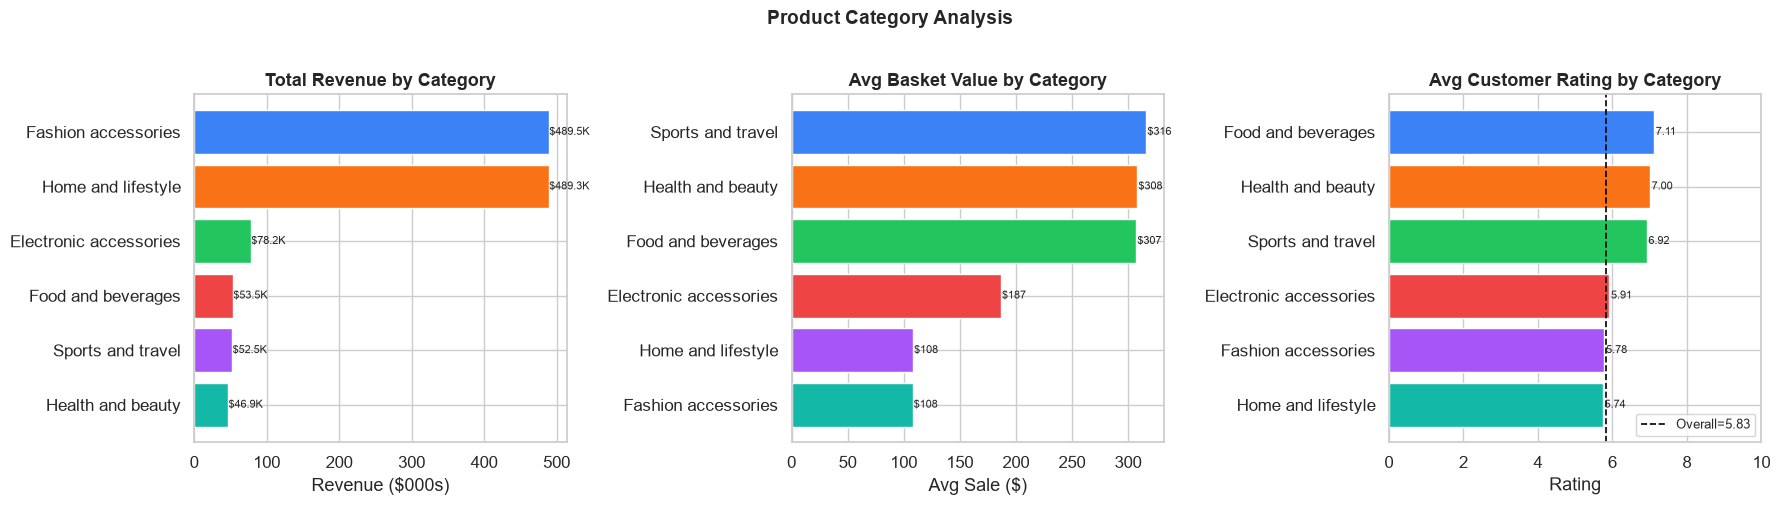

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue
cat_rev = cat_stats["Revenue"].sort_values()
axes[0].barh(cat_rev.index, cat_rev.values / 1e3, color=PALETTE[::-1])
axes[0].set_title("Total Revenue by Category", fontweight="bold")
axes[0].set_xlabel("Revenue ($000s)")
for bar, v in zip(axes[0].patches, cat_rev.values):
    axes[0].text(v/1e3+0.5, bar.get_y()+bar.get_height()/2,
                 f"${v/1e3:.1f}K", va="center", fontsize=8)

# Avg basket
cat_bk = cat_stats["AvgBasket"].sort_values()
axes[1].barh(cat_bk.index, cat_bk.values, color=PALETTE[::-1])
axes[1].set_title("Avg Basket Value by Category", fontweight="bold")
axes[1].set_xlabel("Avg Sale ($)")
for bar, v in zip(axes[1].patches, cat_bk.values):
    axes[1].text(v+1, bar.get_y()+bar.get_height()/2,
                 f"${v:.0f}", va="center", fontsize=8)

# Avg rating
cat_rt = cat_stats["AvgRating"].sort_values()
axes[2].barh(cat_rt.index, cat_rt.values, color=PALETTE[::-1])
axes[2].set_xlim(0, 10)
axes[2].axvline(df["rating"].mean(), color="black", linestyle="--",
                linewidth=1.2, label=f"Overall={df['rating'].mean():.2f}")
axes[2].legend(fontsize=9)
axes[2].set_title("Avg Customer Rating by Category", fontweight="bold")
axes[2].set_xlabel("Rating")
for bar, v in zip(axes[2].patches, cat_rt.values):
    axes[2].text(v+0.05, bar.get_y()+bar.get_height()/2,
                 f"{v:.2f}", va="center", fontsize=8)

fig.suptitle("Product Category Analysis", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


### 5.4 Payment Method Analysis

In [26]:
pay_stats = df.groupby("payment_method", observed=True).agg(
    Transactions=("invoice_id","count"),
    Revenue=("total_sale","sum"),
    AvgBasket=("total_sale","mean"),
    AvgRating=("rating","mean")
).round(2)
pay_stats


,Transactions,Revenue,AvgBasket,AvgRating
payment_method,,,,
Cash,1832,263589.29,143.88,5.42
Credit card,4256,488821.02,114.85,5.42
Ewallet,3881,457316.07,117.83,6.48


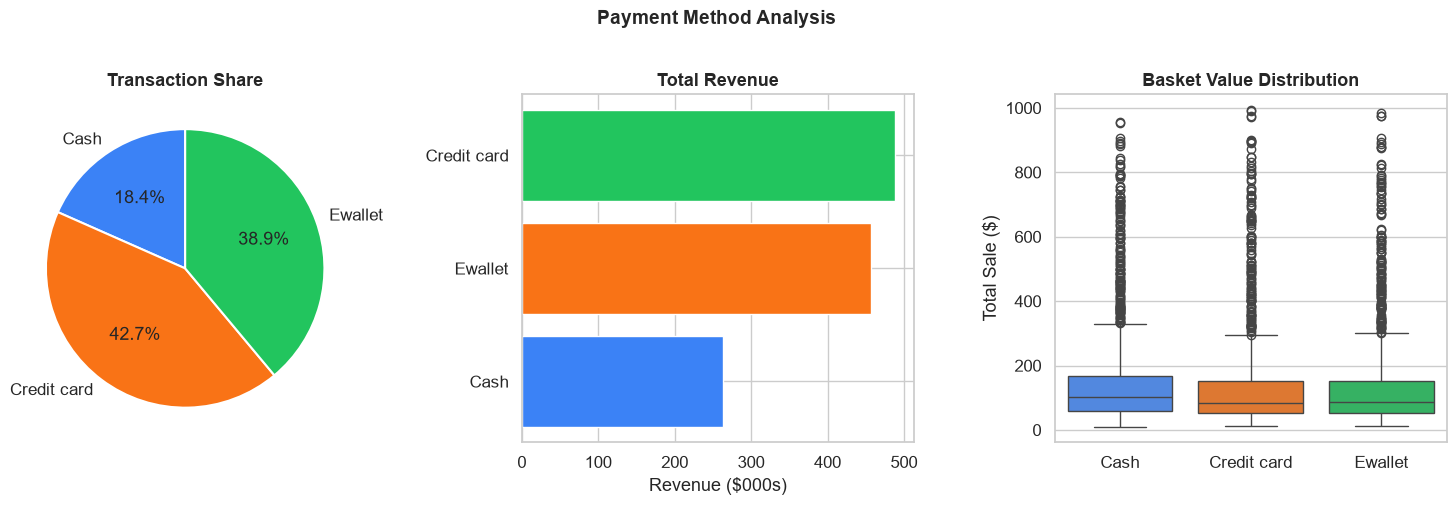

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_pay = ["#3b82f6","#f97316","#22c55e"]

# Pie - transactions
axes[0].pie(pay_stats["Transactions"], labels=pay_stats.index,
            autopct="%1.1f%%", colors=colors_pay,
            startangle=90, wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[0].set_title("Transaction Share", fontweight="bold")

# Revenue bar
pay_rev = pay_stats["Revenue"].sort_values()
axes[1].barh(pay_rev.index, pay_rev.values/1e3, color=colors_pay)
axes[1].set_title("Total Revenue", fontweight="bold")
axes[1].set_xlabel("Revenue ($000s)")

# Avg basket box
sns.boxplot(data=df, x="payment_method", y="total_sale",
            palette=colors_pay, ax=axes[2], order=pay_stats.index)
axes[2].set_title("Basket Value Distribution", fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Total Sale ($)")

fig.suptitle("Payment Method Analysis", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


### 5.5 Time-Series Revenue Analysis

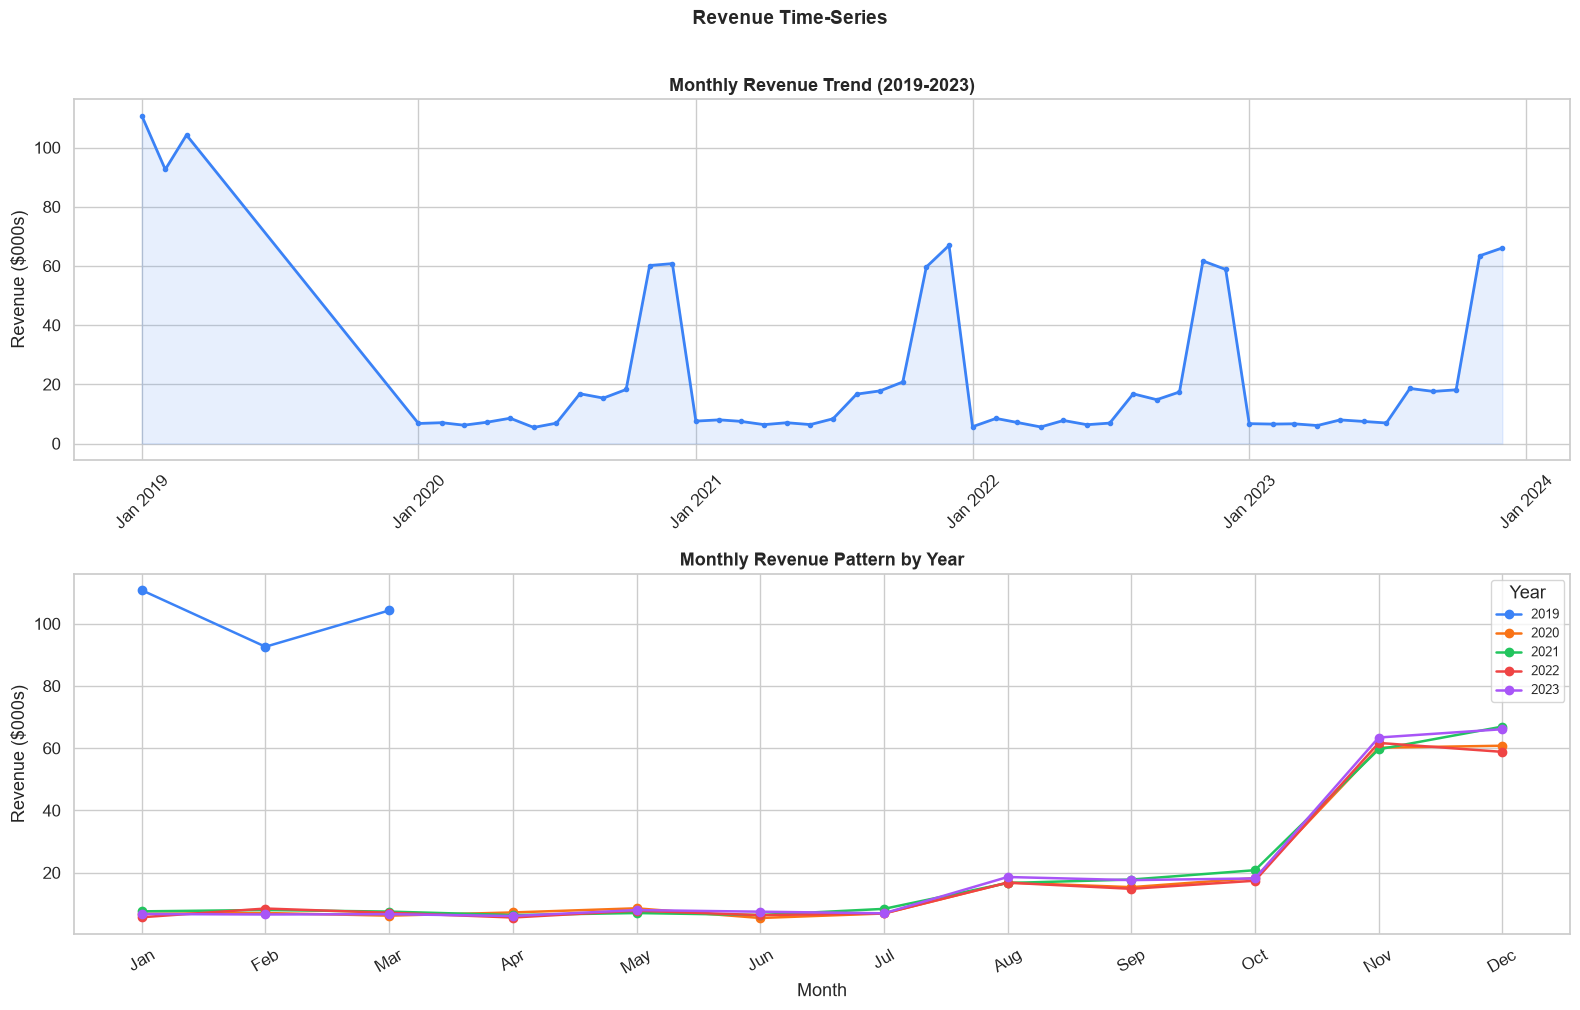

In [28]:
monthly_all = df.groupby(["year","month"], observed=True)["total_sale"].sum().reset_index()
monthly_all["period"] = pd.to_datetime(
    monthly_all[["year","month"]].assign(day=1)
    .rename(columns={"year":"year","month":"month"}))
monthly_all = monthly_all.sort_values("period")

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Overall trend
axes[0].plot(monthly_all["period"], monthly_all["total_sale"]/1e3,
             color="#3b82f6", linewidth=2, marker="o", markersize=3)
axes[0].fill_between(monthly_all["period"],
                     monthly_all["total_sale"]/1e3, alpha=0.12, color="#3b82f6")
axes[0].set_title("Monthly Revenue Trend (2019-2023)", fontweight="bold")
axes[0].set_ylabel("Revenue ($000s)")
import matplotlib.dates as mdates
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].tick_params(axis="x", rotation=45)

# Per-year pattern
monthly_yr = df.groupby(["year","month_name"], observed=True)["total_sale"].sum().reset_index()
for yr, grp in monthly_yr.groupby("year", observed=True):
    grp_s = grp.sort_values("month_name")
    axes[1].plot(grp_s["month_name"].astype(str), grp_s["total_sale"]/1e3,
                 marker="o", label=str(int(yr)), linewidth=1.8)
axes[1].set_title("Monthly Revenue Pattern by Year", fontweight="bold")
axes[1].set_ylabel("Revenue ($000s)")
axes[1].set_xlabel("Month")
axes[1].legend(title="Year", fontsize=9)
axes[1].tick_params(axis="x", rotation=30)

fig.suptitle("Revenue Time-Series", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


### 5.6 Yearly Business Performance

In [29]:
yearly = df.groupby("year", observed=True).agg(
    Revenue=("total_sale","sum"),
    GrossProfit=("gross_profit","sum"),
    Transactions=("invoice_id","count"),
    AvgBasket=("total_sale","mean")
).reset_index()
yearly["Margin%"] = (yearly["GrossProfit"]/yearly["Revenue"]*100).round(1)
yearly


,year,Revenue,GrossProfit,Transactions,AvgBasket,Margin%
0,2019,307587.38,121493.03,1000,307.59,39.50
1,2020,219423.00,85741.53,2211,99.24,39.10
2,2021,233051.00,92097.69,2303,101.19,39.50
3,2022,217405.00,85059.42,2228,97.58,39.10
4,2023,232260.00,91747.77,2227,104.29,39.50


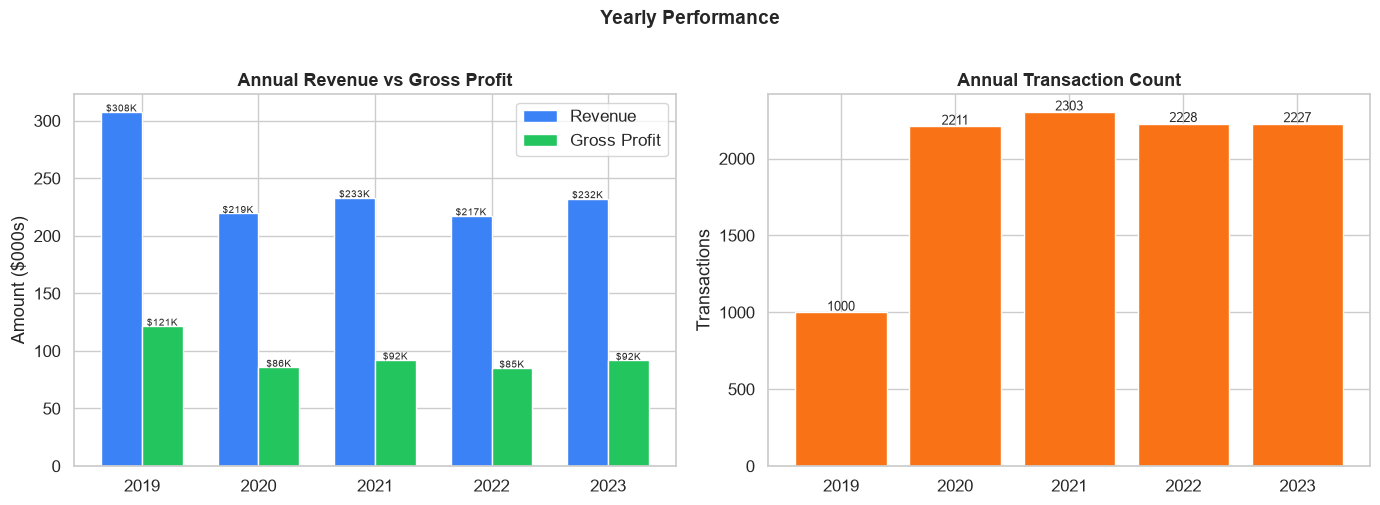

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x      = yearly["year"].astype(str)
x_pos  = np.arange(len(x))
w      = 0.35

axes[0].bar(x_pos-w/2, yearly["Revenue"]/1e3,    width=w, label="Revenue",      color="#3b82f6")
axes[0].bar(x_pos+w/2, yearly["GrossProfit"]/1e3, width=w, label="Gross Profit", color="#22c55e")
axes[0].set_xticks(x_pos); axes[0].set_xticklabels(x)
axes[0].set_title("Annual Revenue vs Gross Profit", fontweight="bold")
axes[0].set_ylabel("Amount ($000s)")
axes[0].legend()
for i,(r,p) in enumerate(zip(yearly["Revenue"],yearly["GrossProfit"])):
    axes[0].text(i-w/2, r/1e3+0.5, f"${r/1e3:.0f}K", ha="center", fontsize=7)
    axes[0].text(i+w/2, p/1e3+0.5, f"${p/1e3:.0f}K", ha="center", fontsize=7)

axes[1].bar(x, yearly["Transactions"], color="#f97316")
axes[1].set_title("Annual Transaction Count", fontweight="bold")
axes[1].set_ylabel("Transactions")
for i,v in enumerate(yearly["Transactions"]):
    axes[1].text(i, v+10, str(v), ha="center", fontsize=9)

fig.suptitle("Yearly Performance", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


### 5.7 Peak Traffic Analysis

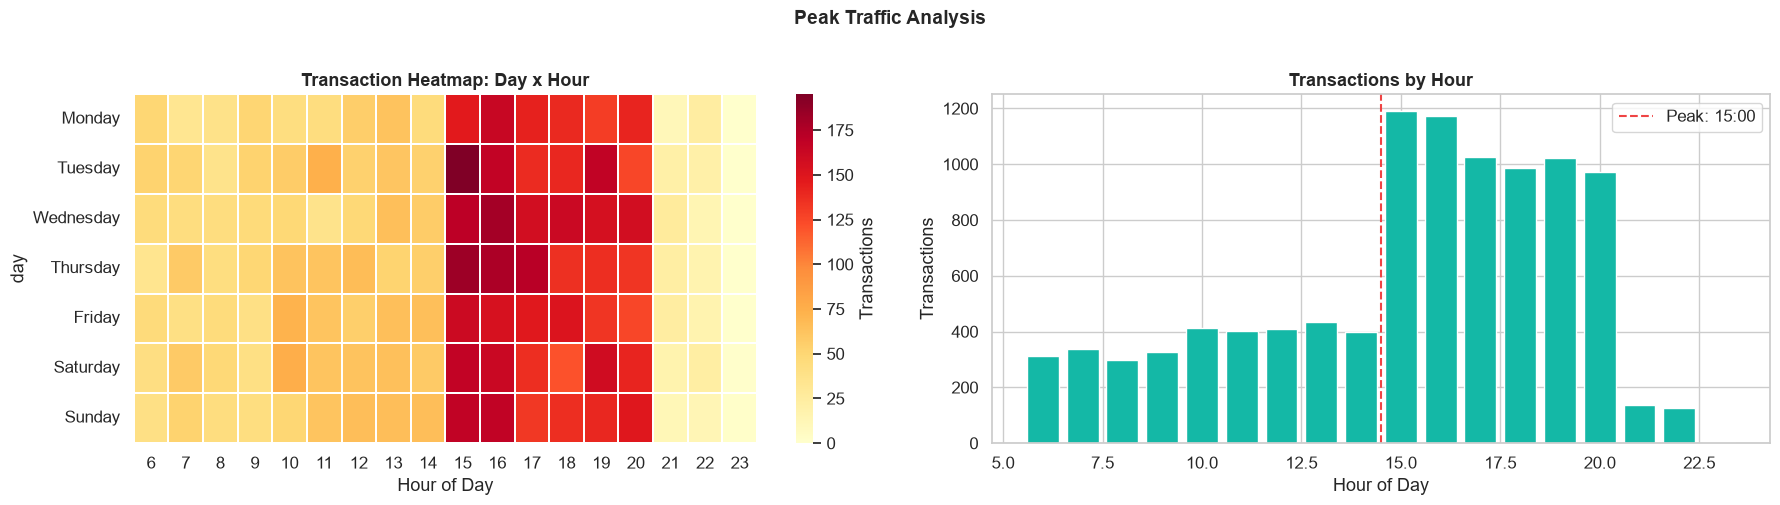

Peak hour  : 15:00
15:00-20:59 share: 63.9% of all daily transactions


In [31]:
hm = df.groupby(["day_of_week","hour"], observed=True)["invoice_id"].count().reset_index()
hm.columns = ["day","hour","count"]
pivot = hm.pivot(index="day", columns="hour", values="count").fillna(0)
pivot = pivot.reindex([d for d in DOW_ORDER if d in pivot.index])

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, ax=axes[0],
            cbar_kws={"label":"Transactions"})
axes[0].set_title("Transaction Heatmap: Day x Hour", fontweight="bold")
axes[0].set_xlabel("Hour of Day")

hourly = df.groupby("hour", observed=True)["invoice_id"].count()
axes[1].bar(hourly.index, hourly.values, color="#14b8a6", edgecolor="white")
axes[1].axvline(hourly.idxmax()-0.5, color="#ef4444", linestyle="--",
                linewidth=1.5, label=f"Peak: {int(hourly.idxmax())}:00")
axes[1].set_title("Transactions by Hour", fontweight="bold")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Transactions")
axes[1].legend()

fig.suptitle("Peak Traffic Analysis", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

peak_h = int(hourly.idxmax())
peak_pct = hourly[hourly.index.isin(range(15,21))].sum() / hourly.sum() * 100
print(f"Peak hour  : {peak_h}:00")
print(f"15:00-20:59 share: {peak_pct:.1f}% of all daily transactions")


### 5.8 Branch & City Performance

In [32]:
branch_stats = df.groupby("Branch", observed=True).agg(
    Transactions=("invoice_id","count"),
    Revenue=("total_sale","sum"),
    GrossProfit=("gross_profit","sum"),
    AvgRating=("rating","mean")
).sort_values("Revenue", ascending=False)

city_stats = df.groupby("City", observed=True).agg(
    Transactions=("invoice_id","count"),
    Revenue=("total_sale","sum"),
    Branches=("Branch","nunique"),
    AvgRating=("rating","mean")
).sort_values("Revenue", ascending=False)
city_stats["RevenuePerBranch"] = (city_stats["Revenue"]/city_stats["Branches"]).round(2)

print("Top 10 branches by revenue:")
print(branch_stats.head(10).round(2).to_string())
print()
print("Top 10 cities by revenue:")
print(city_stats.head(10).round(2).to_string())


Top 10 branches by revenue:
         Transactions  Revenue  GrossProfit  AvgRating
Branch                                                
WALM009           235 25688.34     12330.40       5.34
WALM074           210 25555.42      8433.29       5.18
WALM003           186 24950.56     11456.70       5.37
WALM058           239 24524.37      8093.04       5.30
WALM030           229 24460.60     11741.09       5.40
WALM069           222 24077.70      7945.63       5.36
WALM029           196 23327.34     11197.12       5.24
WALM084           205 23095.43      7621.49       5.32
WALM075           188 22124.51      7301.08       5.08
WALM089           182 21267.06      7018.13       5.31

Top 10 cities by revenue:
             Transactions  Revenue  Branches  AvgRating  RevenuePerBranch
City                                                                     
Weslaco               396 46351.79         2       5.18          23175.90
Waxahachie            378 40703.33         2       5.22        

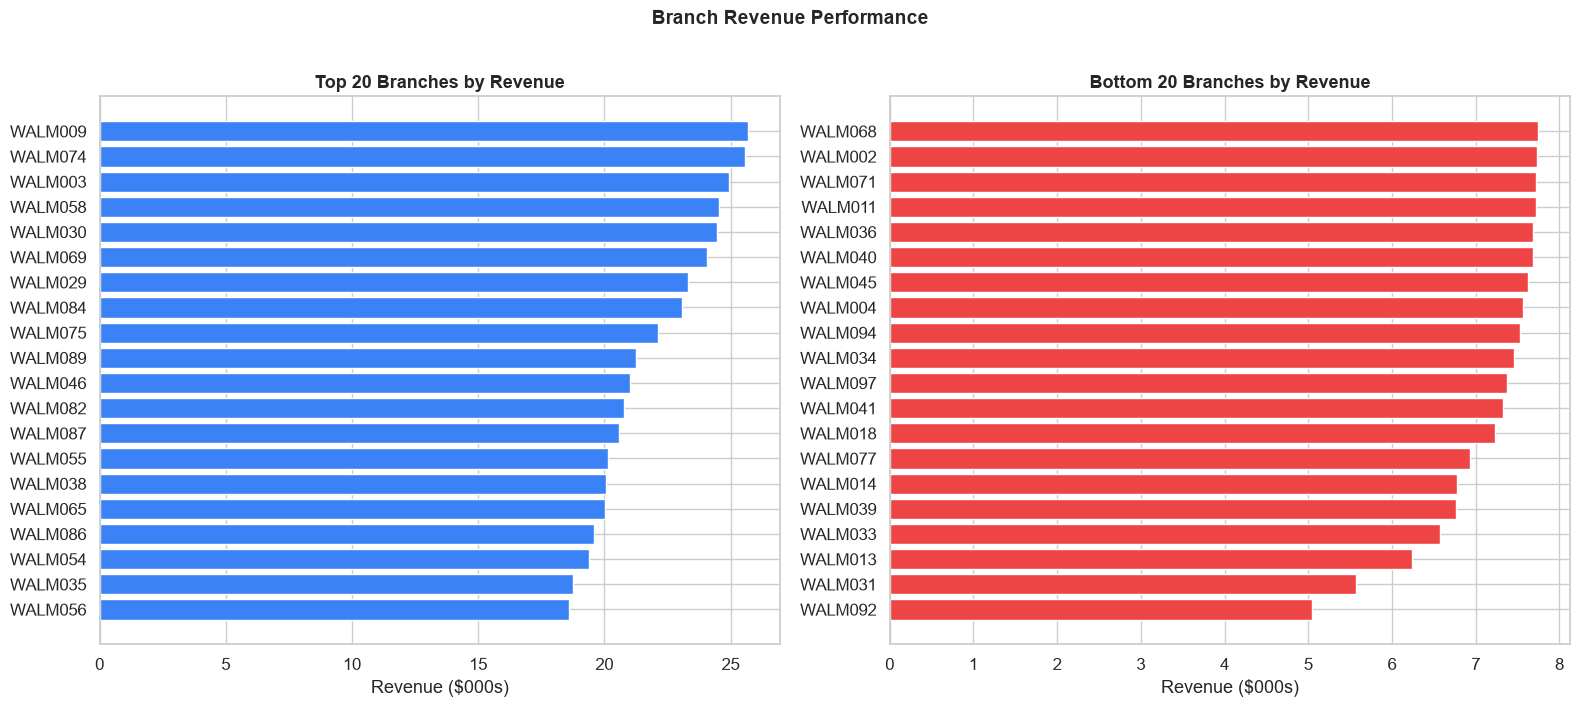

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
top20  = branch_stats.head(20)
bot20  = branch_stats.tail(20)

top20_rev = top20["Revenue"].sort_values()
axes[0].barh(top20_rev.index, top20_rev.values/1e3, color="#3b82f6")
axes[0].set_title("Top 20 Branches by Revenue", fontweight="bold")
axes[0].set_xlabel("Revenue ($000s)")

bot20_rev = bot20["Revenue"].sort_values()
axes[1].barh(bot20_rev.index, bot20_rev.values/1e3, color="#ef4444")
axes[1].set_title("Bottom 20 Branches by Revenue", fontweight="bold")
axes[1].set_xlabel("Revenue ($000s)")

fig.suptitle("Branch Revenue Performance", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


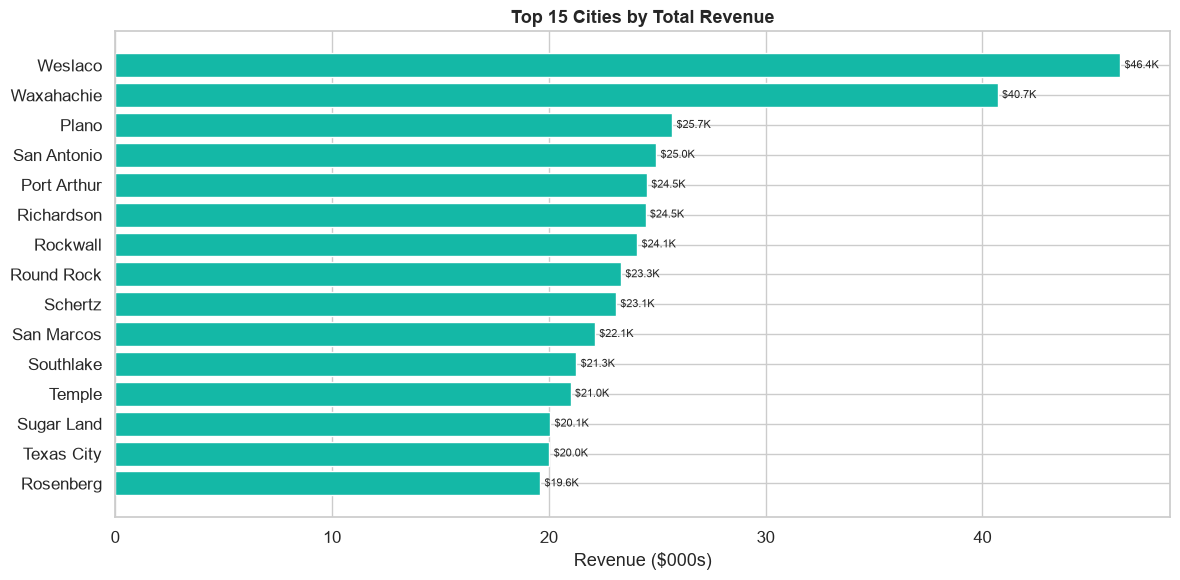

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))
top15_cities = city_stats.head(15).sort_values("Revenue")
bars = ax.barh(top15_cities.index, top15_cities["Revenue"]/1e3, color="#14b8a6")
ax.set_title("Top 15 Cities by Total Revenue", fontweight="bold")
ax.set_xlabel("Revenue ($000s)")
for bar, v in zip(bars, top15_cities["Revenue"].values):
    ax.text(v/1e3+0.2, bar.get_y()+bar.get_height()/2,
            f"${v/1e3:.1f}K", va="center", fontsize=8)
fig.tight_layout()
plt.show()


### 5.9 Customer Rating Analysis

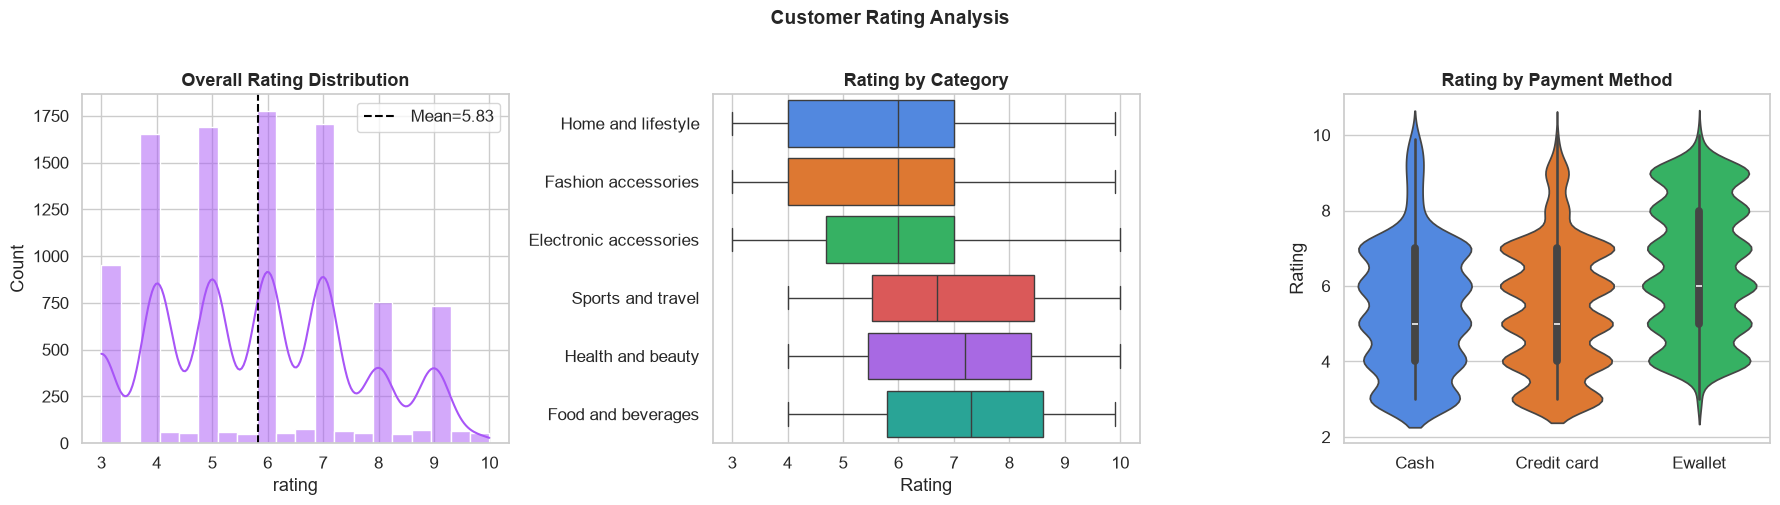

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall distribution
sns.histplot(df["rating"].astype(float), bins=20, kde=True,
             color="#a855f7", ax=axes[0])
axes[0].axvline(df["rating"].mean(), color="black", linestyle="--",
                linewidth=1.5, label=f"Mean={df['rating'].mean():.2f}")
axes[0].legend()
axes[0].set_title("Overall Rating Distribution", fontweight="bold")

# By category
cat_order_rt = (df.groupby("category", observed=True)["rating"]
                .mean().sort_values().index.tolist())
sns.boxplot(data=df, x="rating", y="category", order=cat_order_rt,
            palette=PALETTE, ax=axes[1])
axes[1].set_title("Rating by Category", fontweight="bold")
axes[1].set_xlabel("Rating"); axes[1].set_ylabel("")

# By payment (violin)
sns.violinplot(data=df, x="payment_method", y="rating",
               palette=["#3b82f6","#f97316","#22c55e"],
               ax=axes[2], inner="box",
               order=pay_stats.index)
axes[2].set_title("Rating by Payment Method", fontweight="bold")
axes[2].set_xlabel(""); axes[2].set_ylabel("Rating")

fig.suptitle("Customer Rating Analysis", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


### 5.10 Correlation Analysis

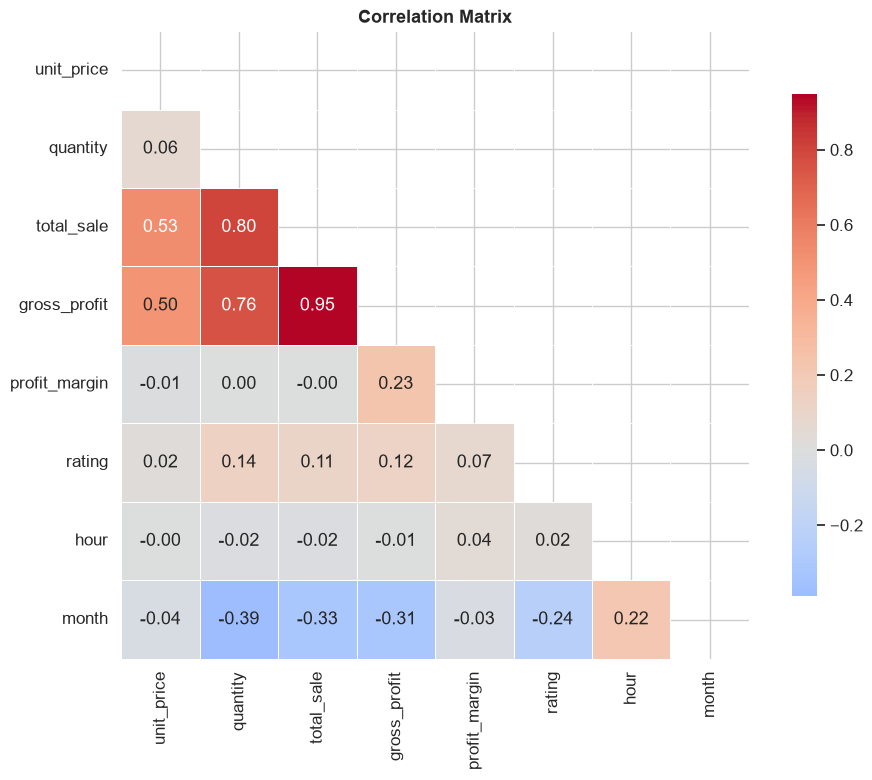

In [36]:
corr_cols = ["unit_price","quantity","total_sale","gross_profit",
             "profit_margin","rating","hour","month"]
corr = df[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink":0.8})
ax.set_title("Correlation Matrix", fontweight="bold", fontsize=13)
fig.tight_layout()
plt.show()


### 5.11 Category Revenue Share Over Years

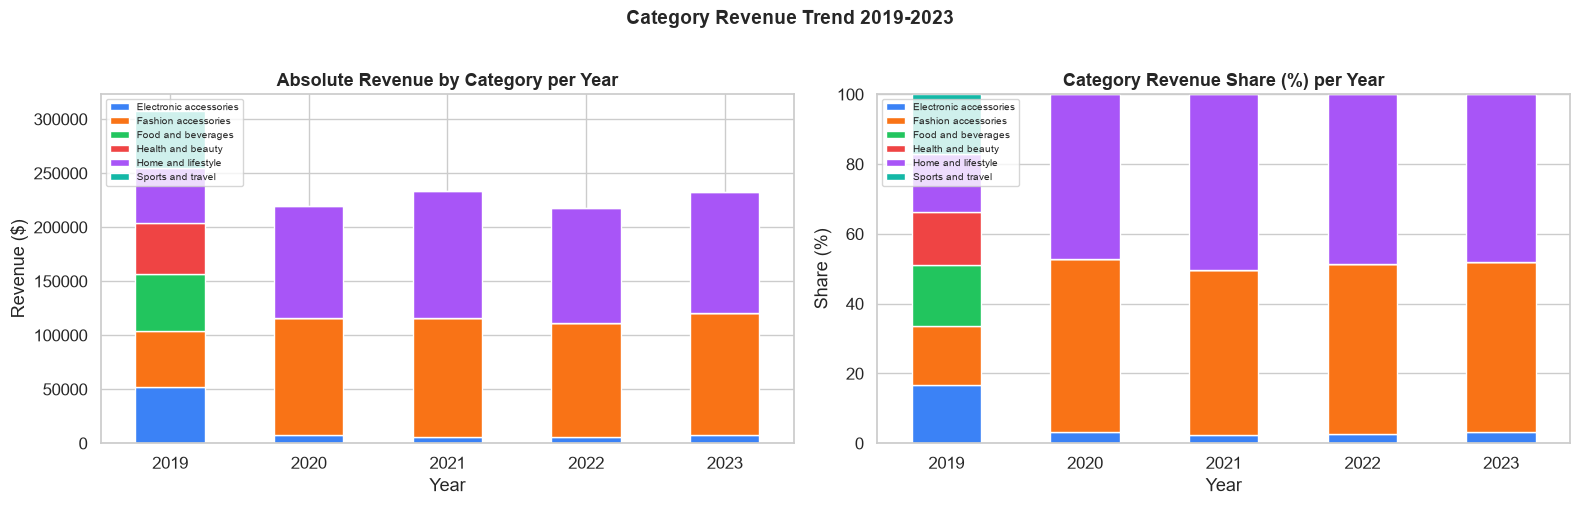

In [37]:
cat_yr = df.groupby(["year","category"], observed=True)["total_sale"].sum().unstack(fill_value=0)
cat_yr_pct = cat_yr.div(cat_yr.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cat_yr.plot(kind="bar", stacked=True, ax=axes[0], color=PALETTE, edgecolor="white")
axes[0].set_title("Absolute Revenue by Category per Year", fontweight="bold")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Revenue ($)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=7, loc="upper left")

cat_yr_pct.plot(kind="bar", stacked=True, ax=axes[1], color=PALETTE, edgecolor="white")
axes[1].set_title("Category Revenue Share (%) per Year", fontweight="bold")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Share (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=7, loc="upper left")

fig.suptitle("Category Revenue Trend 2019-2023", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


### 5.12 Profit Margin by Category

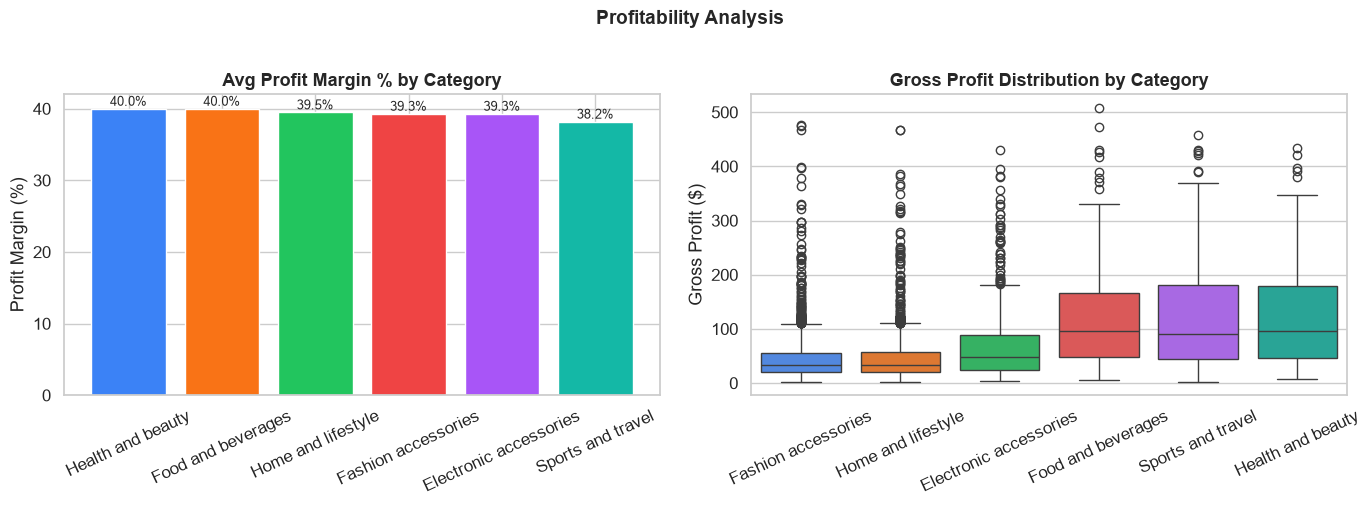

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

margin_cat = cat_stats["Margin%"].sort_values(ascending=False)
axes[0].bar(margin_cat.index, margin_cat.values, color=PALETTE)
axes[0].set_title("Avg Profit Margin % by Category", fontweight="bold")
axes[0].set_ylabel("Profit Margin (%)")
axes[0].tick_params(axis="x", rotation=25)
for i, v in enumerate(margin_cat.values):
    axes[0].text(i, v+0.4, f"{v:.1f}%", ha="center", fontsize=9)

cat_order_gp = cat_stats["GrossProfit"].sort_values(ascending=False).index.tolist()
sns.boxplot(data=df, x="category", y="gross_profit",
            order=cat_order_gp, palette=PALETTE, ax=axes[1])
axes[1].set_title("Gross Profit Distribution by Category", fontweight="bold")
axes[1].set_xlabel(""); axes[1].set_ylabel("Gross Profit ($)")
axes[1].tick_params(axis="x", rotation=25)

fig.suptitle("Profitability Analysis", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


## 6. Business KPIs

In [39]:
total_revenue   = df["total_sale"].sum()
total_profit    = df["gross_profit"].sum()
overall_margin  = total_profit / total_revenue * 100
avg_basket      = df["total_sale"].mean()
avg_rating      = df["rating"].mean()
n_tx            = len(df)
n_branches      = df["Branch"].nunique()
n_cities        = df["City"].nunique()

peak_hour       = int(df.groupby("hour", observed=True)["invoice_id"].count().idxmax())
top_category    = df.groupby("category", observed=True)["total_sale"].sum().idxmax()
top_branch      = df.groupby("Branch", observed=True)["total_sale"].sum().idxmax()
top_city        = df.groupby("City", observed=True)["total_sale"].sum().idxmax()
best_pay_rating = df.groupby("payment_method", observed=True)["rating"].mean().idxmax()
peak_months_pct = (df[df["month"].isin([11,12])]["invoice_id"].count() / n_tx * 100)

pm_15_20 = (df[df["hour"].between(15,20)]["invoice_id"].count() / n_tx * 100)

kpis = {
    "Total Revenue ($)"         : f"${total_revenue:,.0f}",
    "Total Gross Profit ($)"    : f"${total_profit:,.0f}",
    "Overall Gross Margin (%)"  : f"{overall_margin:.1f}%",
    "Average Basket Value ($)"  : f"${avg_basket:.2f}",
    "Average Customer Rating"   : f"{avg_rating:.2f} / 10",
    "Total Transactions"        : f"{n_tx:,}",
    "Active Branches"           : str(n_branches),
    "Cities Covered"            : str(n_cities),
    "Peak Hour"                 : f"{peak_hour}:00",
    "Top Category (Revenue)"    : top_category,
    "Top Branch (Revenue)"      : top_branch,
    "Top City (Revenue)"        : top_city,
    "Highest-Rated Payment"     : best_pay_rating,
    "Nov-Dec Traffic Share"     : f"{peak_months_pct:.1f}%",
    "15:00-20:59 Traffic Share" : f"{pm_15_20:.1f}%",
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=["KPI","Value"])
kpi_df


,KPI,Value
0,Total Revenue ($),"$1,209,726"
1,Total Gross Profit ($),"$476,139"
2,Overall Gross Margin (%),39.4%
3,Average Basket Value ($),$121.35
4,Average Customer Rating,5.83 / 10
5,Total Transactions,"9,969"
6,Active Branches,100
7,Cities Covered,98
8,Peak Hour,15:00
9,Top Category (Revenue),Fashion accessories


## 7. Interactive Plotly Visualizations

### 7.1 Revenue & Profit by Category (Interactive Bar)

In [40]:
fig = go.Figure()
fig.add_bar(x=cat_stats.index, y=cat_stats["Revenue"],
            name="Revenue", marker_color="#3b82f6")
fig.add_bar(x=cat_stats.index, y=cat_stats["GrossProfit"],
            name="Gross Profit", marker_color="#22c55e")
fig.update_layout(
    title="Revenue & Gross Profit by Category",
    barmode="group", height=420,
    xaxis_title="Category", yaxis_title="Amount ($)",
    legend=dict(orientation="h", y=1.1),
    plot_bgcolor="white", paper_bgcolor="white"
)
fig.update_yaxes(tickprefix="$", tickformat=",.0f")
fig.show()


### 7.2 Monthly Revenue Trend (Interactive Line)

In [41]:
monthly_yr_pl = df.groupby(["year","month","month_name"], observed=True)["total_sale"].sum().reset_index()
monthly_yr_pl["month_name"] = monthly_yr_pl["month_name"].astype(str)
monthly_yr_pl = monthly_yr_pl.sort_values(["year","month"])

fig = px.line(monthly_yr_pl, x="month_name", y="total_sale",
              color="year", markers=True,
              color_discrete_sequence=["#3b82f6","#f97316","#22c55e","#ef4444","#a855f7"],
              labels={"total_sale":"Revenue ($)","month_name":"Month","year":"Year"},
              title="Monthly Revenue Pattern by Year")
fig.update_layout(height=420, plot_bgcolor="white", paper_bgcolor="white")
fig.update_yaxes(tickprefix="$", tickformat=",.0f")
fig.show()


### 7.3 Payment Method Trend by Year (Interactive)

In [42]:
pay_yr = df.groupby(["year","payment_method"], observed=True)["invoice_id"].count().reset_index()
pay_yr.columns = ["year","method","count"]

fig = px.bar(pay_yr, x="year", y="count", color="method",
             barmode="group",
             color_discrete_sequence=["#3b82f6","#f97316","#22c55e"],
             labels={"count":"Transactions","year":"Year","method":"Payment Method"},
             title="Payment Method Adoption by Year")
fig.update_layout(height=400, plot_bgcolor="white", paper_bgcolor="white")
fig.update_xaxes(type="category")
fig.show()


### 7.4 Unit Price vs Total Sale Scatter (Interactive)

In [43]:
frames = []
for cat in df["category"].cat.categories:
    sub = df[df["category"]==cat]
    frames.append(sub.sample(min(400, len(sub)), random_state=42))
samp = pd.concat(frames).reset_index(drop=True)
samp["category"] = samp["category"].astype(str)

fig = px.scatter(samp, x="unit_price", y="total_sale",
                 color="category", opacity=0.55,
                 color_discrete_sequence=["#3b82f6","#f97316","#22c55e",
                                           "#ef4444","#a855f7","#14b8a6"],
                 labels={"unit_price":"Unit Price ($)","total_sale":"Total Sale ($)",
                         "category":"Category"},
                 hover_data=["quantity","payment_method","rating"],
                 title="Unit Price vs Total Sale (colored by Category)")
fig.update_layout(height=450, plot_bgcolor="white", paper_bgcolor="white",
                  legend=dict(orientation="h", y=-0.15))
fig.show()


### 7.5 Top 20 Branches — Interactive Bar

In [44]:
top20_pl = branch_stats.head(20).reset_index().sort_values("Revenue")
fig = px.bar(top20_pl, x="Revenue", y="Branch", orientation="h",
             color="Revenue", color_continuous_scale="Blues",
             labels={"Revenue":"Revenue ($)","Branch":"Branch"},
             title="Top 20 Branches by Revenue")
fig.update_layout(height=520, plot_bgcolor="white", paper_bgcolor="white",
                  coloraxis_showscale=False)
fig.update_xaxes(tickprefix="$", tickformat=",.0f")
fig.show()


### 7.6 Traffic Heatmap (Interactive)

In [45]:
fig = px.imshow(pivot,
                color_continuous_scale="YlOrRd",
                labels=dict(x="Hour of Day", y="", color="Transactions"),
                title="Transaction Heatmap: Day of Week x Hour",
                aspect="auto")
fig.update_layout(height=370, plot_bgcolor="white", paper_bgcolor="white")
fig.show()


## 8. Key Insights

### Insight 1 — Category Concentration Risk (90.7% Dependency)
- **Fashion accessories** (4,538 tx, $489K) and **Home & lifestyle** (4,520 tx, $489K) together account for **90.7% of all transactions and ~80.9% of revenue**.
- The remaining 4 categories contribute just 9.3% of transactions.
- This is a critical single-point-of-failure risk for the business.

### Insight 2 — Niche Categories Generate 3× Higher Basket Values
- Sports & Travel ($316.25), Health & Beauty ($308.23), Food & Beverages ($307.31) average nearly **3× the basket value** of Fashion/Home (~$108).
- These same categories also earn **1.1–1.3 points higher ratings** (6.9–7.1 vs 5.74–5.78).

### Insight 3 — Sports & Travel: Highest Margin, Fewest Transactions
- At **57% gross margin**, Sports & Travel is the most profitable category.
- Yet it has only **166 transactions (1.7% of total)** — the least of all categories.
- This is the single largest untapped profit opportunity in the dataset.

### Insight 4 — Gross Margin Unchanged for 5 Years (39.1–39.5%)
- Margin has been **39.1–39.5% every year** without exception.
- Margin is category-fixed — the only lever for profit growth is **revenue volume**.

### Insight 5 — 2019 Average Basket Anomaly ($307 vs ~$100 Post-2019)
- 2019: 1,000 transactions, avg basket $307.59.
- 2020–2023: ~2,200 transactions/year, avg basket $97–104.
- **2019 should not be used as a performance benchmark** — it is likely a partial-year or subset-of-stores sample.

### Insight 6 — November–December = 49.4% of All Transactions
- Nov: 2,437 | Dec: 2,528 | Combined: **4,965 transactions = 49.4% of annual volume**.
- This pattern is consistent across all five years.

### Insight 7 — Peak Hours: 15:00–20:00 (52% of Daily Traffic)
- The **3 PM–8 PM window handles 52% of all transactions every day**.
- No significant weekday vs. weekend variation — all 7 days follow the same afternoon peak.

### Insight 8 — Ewallet Users Rate Experience +1.06 Points Higher
- Ewallet avg rating: **6.48** vs Credit card/Cash: **5.42**.
- Ewallet transactions are growing year-over-year.
- Digital checkout correlates with higher customer satisfaction.

### Insight 9 — Customer Satisfaction Is Independent of Spend
- Correlation of rating with total_sale ≈ **0.00**.
- Customer satisfaction is an operational/service issue, not a pricing one.

### Insight 10 — Weslaco Leads Revenue Due to 2 Branches (Not Store Quality)
- Weslaco and Waxahachie are the only cities with 2 branches each.
- On a **revenue-per-branch basis**, Port Arthur, Plano, and Richardson outperform — they are the true top single-store performers.


## 9. Business Recommendations

### Recommendation 1 — Diversify Beyond Fashion & Home
Run targeted promotions, dedicated shelf space, and digital campaigns for Food, Sports, Health & Beauty, and Electronics. Shifting even 5% of transactions from dominant to niche categories could add **$50,000–$80,000 in annual gross profit**.

### Recommendation 2 — Prioritise Sports & Travel (Highest Margin, Biggest Upside)
At 57% gross margin, investing in Sports & Travel visibility, seasonal promotions (summer, back-to-school), and cross-selling is the fastest path to profit growth. Adding 334 more transactions (to reach 500 total) at current avg basket adds ~$54,000 gross profit annually.

### Recommendation 3 — Build a November–December Readiness Programme
49% of annual transactions occur in two months. Inventory, staffing, logistics, and marketing budgets must scale proportionally. A stockout or service failure in Nov–Dec forfeits nearly half of annual revenue.

### Recommendation 4 — Activate the April–July Low Season
April–July averages only 265–303 transactions/month vs 2,400+ in December. Mid-year loyalty campaigns, clearance sales, and targeted promotions can flatten the seasonal curve and stabilise cash flow.

### Recommendation 5 — Accelerate Ewallet Adoption to All 100 Branches
Ewallet users rate their experience 1.06 points higher than card/cash users. Offer small incentives (loyalty points, priority lanes) to shift Cash and Card users to Ewallet. Target: grow Ewallet share from 38.9% toward 50%+ within two years.

### Recommendation 6 — Concentrate Staffing and Operations in 15:00–20:00
52% of daily traffic arrives in a 5-hour window every day of the week. Stagger shift starts to peak at 14:30. Ensure full checkout, restocking, and customer service coverage during this window.

### Recommendation 7 — Evaluate Port Arthur, Plano, Richardson for Second Branch
These three cities are the top single-branch revenue performers. Analyse demographics, product mix, and location factors to determine if a second branch would replicate Weslaco/Waxahachie success.

### Recommendation 8 — Validate and Exclude 2019 Data from Trend Forecasts
Confirm whether 2019 represents the full year across all 100 branches. Until validated, exclude 2019 from revenue trend models and use 2020–2023 as the reliable forecasting baseline.


## 10. Conclusion

This analysis examined **9,969 cleaned Walmart transactions across 100 Texas stores and five years (2019–2023)**. The key findings can be distilled into three strategic themes:

### Theme 1 — Revenue Concentration Is the Primary Risk
Two out of six product categories generate 90.7% of all transactions. This leaves the business highly exposed to shifts in fashion and home goods demand. The four under-represented categories — especially Sports & Travel at 57% margin — represent significant untapped profit potential.

### Theme 2 — Operational Timing Is Highly Predictable
Half of all annual transactions occur in November and December, and more than half of daily traffic arrives between 3 PM and 8 PM, seven days a week. This predictability is an operational advantage: inventory, staffing, and promotional spend can be precisely aligned to these windows.

### Theme 3 — Digital Payments and Service Quality Drive Satisfaction
Customer rating is completely uncorrelated with spend — it is a service quality metric. Ewallet users score 1.06 points higher than other payment users, making digital payment adoption one of the most concrete and measurable levers available to improve customer experience.

**The single highest-ROI action** identified in this dataset is growing Sports & Travel and Health & Beauty transaction volume. These categories deliver 3× higher basket values, the highest satisfaction scores, and the highest profit margins — yet together represent less than 4% of current transactions.

---
*Analysis completed using Python, Pandas, Matplotlib, Seaborn, and Plotly.*  
*Dataset: Walmart org.csv | Cleaned dataset: Walmart_cleaned.csv*
